# NLP 第三方库环境测试

## Goal

验证 Jupyter Notebook 是否正在使用 `course1_365` 环境，并用轻量示例实际运行课程所需的主要第三方库。

本 Notebook 已按从上到下的顺序执行；每个单元格的输出就是对应库的运行证据。

## Setup

先确认 Python 解释器路径和主要库版本。解释器应位于 `D:\1\ana\envs\course1_365`。

In [1]:
import sys
from importlib.metadata import version

packages = [
    "nltk", "pandas", "matplotlib", "spacy", "textblob",
    "vaderSentiment", "transformers", "scikit-learn", "gensim",
    "seaborn", "torch", "ipywidgets"
]

print("Python 版本：", sys.version.split()[0])
print("Python 路径：", sys.executable)
print("\n主要库版本：")
for package in packages:
    print(f"{package:16} {version(package)}")

assert "course1_365" in sys.executable, "当前内核没有使用 course1_365 环境"
checks = {"环境路径": True}

Python 版本： 3.14.7
Python 路径： D:\1\ana\envs\course1_365\python.exe

主要库版本：
nltk             3.10.3
pandas           3.0.5
matplotlib       3.11.1
spacy            3.8.16
textblob         0.20.1
vaderSentiment   3.3.2
transformers     5.16.1
scikit-learn     1.9.0
gensim           4.4.0
seaborn          0.13.2
torch            2.13.0
ipywidgets       8.1.9


## Steps

### 1. pandas 数据处理

创建一个小型酒店评论表，并计算评分均值。

In [2]:
import pandas as pd

reviews = pd.DataFrame({
    "review": ["great room", "friendly staff", "expensive parking"],
    "rating": [5, 4, 2],
})

display(reviews)
print("平均评分：", round(reviews["rating"].mean(), 2))
checks["pandas"] = reviews.shape == (3, 2)

,review,rating
0,great room,5
1,friendly staff,4
2,expensive parking,2


平均评分： 3.67


### 2. Matplotlib 与 Seaborn 可视化

绘制评分柱状图，验证绘图库能在 Notebook 内产生图像输出。

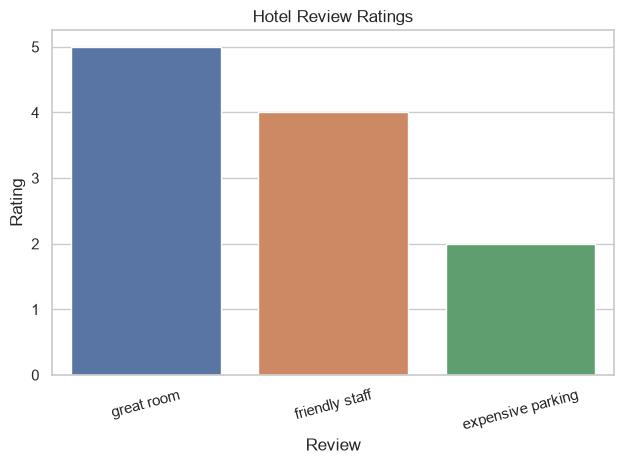

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
ax = sns.barplot(data=reviews, x="review", y="rating", hue="review", legend=False)
ax.set(title="Hotel Review Ratings", xlabel="Review", ylabel="Rating")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

checks["matplotlib + seaborn"] = True

### 3. NLTK、TextBlob 与 VADER

- NLTK：完成不依赖额外语料包的基础分词。
- TextBlob、VADER：对同一句评论计算情感结果。

In [4]:
from nltk.tokenize import wordpunct_tokenize
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sample_text = "The room was clean and the staff were very friendly!"
tokens = wordpunct_tokenize(sample_text.lower())
textblob_sentiment = TextBlob(sample_text).sentiment
vader_scores = SentimentIntensityAnalyzer().polarity_scores(sample_text)

print("NLTK 分词：", tokens)
print("TextBlob 情感：", textblob_sentiment)
print("VADER 情感：", vader_scores)

checks["NLTK"] = len(tokens) > 0
checks["TextBlob"] = textblob_sentiment.polarity > 0
checks["VADER"] = vader_scores["compound"] > 0

NLTK 分词： ['the', 'room', 'was', 'clean', 'and', 'the', 'staff', 'were', 'very', 'friendly', '!']
TextBlob 情感： Sentiment(polarity=0.48802083333333335, subjectivity=0.675)
VADER 情感： {'neg': 0.0, 'neu': 0.552, 'pos': 0.448, 'compound': 0.7569}


### 4. spaCy 英文模型

加载 `en_core_web_sm`，执行分词、词形还原和词性标注。

In [5]:
import spacy

nlp = spacy.load("en_core_web_sm")
doc = nlp("The rooms were clean and comfortable.")
spacy_result = [(token.text, token.lemma_, token.pos_) for token in doc]

print("spaCy 结果：")
for item in spacy_result:
    print(item)

checks["spaCy + en_core_web_sm"] = len(spacy_result) > 0

spaCy 结果：
('The', 'the', 'DET')
('rooms', 'room', 'NOUN')
('were', 'be', 'AUX')
('clean', 'clean', 'ADJ')
('and', 'and', 'CCONJ')
('comfortable', 'comfortable', 'ADJ')
('.', '.', 'PUNCT')


### 5. scikit-learn 与 Gensim

- scikit-learn：把评论转换成 TF-IDF 特征。
- Gensim：在极小语料上训练 Word2Vec，仅用于验证安装。

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

documents = ["clean comfortable room", "friendly helpful staff", "expensive parking"]
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(documents)

sentences = [document.split() for document in documents]
word2vec = Word2Vec(sentences=sentences, vector_size=10, window=2, min_count=1, workers=1, epochs=20, seed=42)

print("TF-IDF 形状：", tfidf_matrix.shape)
print("TF-IDF 词汇：", tfidf.get_feature_names_out().tolist())
print("Word2Vec 词向量维度：", word2vec.wv["room"].shape)

checks["scikit-learn"] = tfidf_matrix.shape[0] == 3
checks["Gensim"] = word2vec.wv["room"].shape == (10,)

TF-IDF 形状： (3, 8)
TF-IDF 词汇： ['clean', 'comfortable', 'expensive', 'friendly', 'helpful', 'parking', 'room', 'staff']
Word2Vec 词向量维度： (10,)


### 6. Transformers 与 PyTorch

创建一个很小的随机 BERT 模型完成前向计算。该测试不下载预训练模型，只验证 Transformers 与 PyTorch 能协同运行。

In [7]:
import torch
from transformers import BertConfig, BertModel

config = BertConfig(
    vocab_size=100,
    hidden_size=16,
    num_hidden_layers=1,
    num_attention_heads=2,
    intermediate_size=32,
)
model = BertModel(config)
input_ids = torch.tensor([[1, 5, 8, 2]])

with torch.no_grad():
    output = model(input_ids=input_ids)

print("PyTorch 版本：", torch.__version__)
print("BERT 输出形状：", tuple(output.last_hidden_state.shape))

checks["Transformers + PyTorch"] = tuple(output.last_hidden_state.shape) == (1, 4, 16)

PyTorch 版本： 2.13.0+cpu
BERT 输出形状： (1, 4, 16)


### 7. ipywidgets

创建一个滑块，验证 Jupyter 小组件可以生成。

In [8]:
import ipywidgets as widgets
from IPython.display import display

slider = widgets.IntSlider(value=3, min=0, max=5, description="Rating")
display(slider)

checks["ipywidgets"] = slider.value == 3

IntSlider(value=3, description='Rating', max=5)

## Checks

汇总所有测试。只有全部通过，最后一个断言才会成功。

In [9]:
status_table = pd.DataFrame(
    [{"检查项目": name, "状态": "通过" if passed else "失败"} for name, passed in checks.items()]
)

display(status_table)
assert all(checks.values()), "存在未通过的第三方库测试"
print(f"全部通过：{sum(checks.values())}/{len(checks)} 项检查成功。")

,检查项目,状态
0,环境路径,通过
1,pandas,通过
2,matplotlib + seaborn,通过
3,NLTK,通过
4,TextBlob,通过
5,VADER,通过
6,spaCy + en_core_web_sm,通过
7,scikit-learn,通过
8,Gensim,通过
9,Transformers + PyTorch,通过


全部通过：11/11 项检查成功。


## Next Steps

环境测试已经完成。后续课程 Notebook 可以直接选择 `Python (course1_365)` 内核，并按需要使用以上库。